In [ ]:
# (1) 첨부된 code에서 Q-Learning이 어떻게 적용되었는지 정리해보세요!
# (2) 코드에서 gamma 값을 0.5 또는 0.99로 바꾸어 실행해보고, gamma 값을 다르게 설정하면 Q-matrix가 어떻게 변하는지 비교하여 정리해보세요!

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt

gamma = 0.8

#For matrices reward and q_matrix columns are in order (U, D, L, R, N)

# here the states are 0, 1, 2, 3 for convenience
# 0 is the startinf state
# 1 is state to the right of 0
# 2 is the snake-pit state
# 3 is the treasure(goal state)

reward = np.array([[0, -10, 0, -1, -1],
         [0, 10, -1, 0, -1],
         [-1, 0, 0, 10, -1],
         [-1, 0, -10, 0, 10]])

q_matrix = np.zeros((4,5))

# -1 represent invalid transitions
transition_matrix = np.array([[-1, 2, -1, 1, 0],
                  [-1, 3, 0, -1, 1],
                  [0, -1, -1, 3, 2],
                  [1, -1, 2, -1, 3]])

# for valid actions
# encode up as 0, down as 1, left as 2, right as 3, no action as 4
# the rows are the states
valid_action = np.array([[1, 3, 4],
             [1, 2, 4],
             [0, 3, 4],
             [0, 2, 4]])

for i in range(10): # 10 episodes
    start_state = 0
    current_state = start_state
    while current_state != 3:
        action = random.choice(valid_action[current_state])
        next_state = transition_matrix[current_state][action]
        future_rewards =[]
        for action_nxt in valid_action[next_state]:
            future_rewards.append(q_matrix[next_state][action_nxt])
        q_state = reward[current_state][action] + gamma*max(future_rewards)
        q_matrix[current_state][action] = q_state
        print(q_matrix)
        print('Q-matrix is updated')
        current_state = next_state
        if current_state == 3:
            print('goal state reached')

print('final q-matrix : ')
print(q_matrix)


[[  0. -10.   0.   0.   0.]
 [  0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.]]
Q-matrix is updated
[[  0. -10.   0.   0.   0.]
 [  0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.  -1.]
 [  0.   0.   0.   0.   0.]]
Q-matrix is updated
[[  0. -10.   0.   0.   0.]
 [  0.   0.   0.   0.   0.]
 [ -1.   0.   0.   0.  -1.]
 [  0.   0.   0.   0.   0.]]
Q-matrix is updated
[[  0. -10.   0.  -1.   0.]
 [  0.   0.   0.   0.   0.]
 [ -1.   0.   0.   0.  -1.]
 [  0.   0.   0.   0.   0.]]
Q-matrix is updated
[[  0. -10.   0.  -1.   0.]
 [  0.  10.   0.   0.   0.]
 [ -1.   0.   0.   0.  -1.]
 [  0.   0.   0.   0.   0.]]
Q-matrix is updated
goal state reached
[[  0. -10.   0.  -1.   0.]
 [  0.  10.   0.   0.   0.]
 [ -1.   0.   0.   0.  -1.]
 [  0.   0.   0.   0.   0.]]
Q-matrix is updated
[[  0. -10.   0.  -1.   0.]
 [  0.  10.   0.   0.   0.]
 [ -1.   0.   0.   0.  -1.]
 [  0.   0.   0.   0.   0.]]
Q-matrix is updated
[[  0. -10.   0.  -1.   0.]
 [  0.  10.   0.   0. 

(1) Q-Learning 적용 방식:

Q-Learning은 강화 학습에서 에이전트가 환경을 탐험하고 보상을 통해 최적의 행동 정책을 학습하는 방법입니다.

초기화:

  q_matrix: 모든 상태-행동 쌍에 대한 Q값을 0으로 초기화합니다.

  reward: 각 상태-행동 쌍에 대한 보상 값을 저장한 행렬입니다.

  transition_matrix: 상태-행동에 따라 다음 상태로의 전이를 나타냅니다.

  valid_action: 각 상태에서 가능한 행동(행동은 상, 하, 좌, 우, 아무 것도 안 하기)을 정의합니다.



반복적인 학습 (10번의 에포크):

시작 상태는 항상 0 (시작 상태)입니다.

에이전트는 현재 상태에서 가능한 행동 중 하나를 무작위로 선택합니다.

선택된 행동에 해당하는 next_state를 transition_matrix를 통해 구합니다.

선택된 행동에 대해 Q값을 갱신합니다. Q값 갱신은 다음과 같이 이루어집니다.
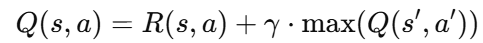

여기서:

R(s, a): 현재 상태에서 해당 행동을 취했을 때의 보상입니다.

γ: 할인 계수로, 미래 보상의 중요도를 결정합니다.

max(Q(s', a')): 다음 상태에서 가능한 행동 중 가장 큰 Q값을 선택하여 업데이트합니다.

Q값을 갱신한 후, 에이전트는 next_state로 이동하고 목표 상태(3)에 도달하면 종료합니다.

목표 상태 도달:

목표 상태(3)에 도달하면 "goal state reached"라는 메시지를 출력합니다.

Q-matrix 업데이트:

각 에피소드가 끝날 때마다 Q-matrix가 갱신되며, 최종적으로 Q-matrix가 출력됩니다.


In [2]:
import numpy as np
import random
import matplotlib.pyplot as plt

gamma = 0.5

#For matrices reward and q_matrix columns are in order (U, D, L, R, N)

# here the states are 0, 1, 2, 3 for convenience
# 0 is the startinf state
# 1 is state to the right of 0
# 2 is the snake-pit state
# 3 is the treasure(goal state)

reward = np.array([[0, -10, 0, -1, -1],
         [0, 10, -1, 0, -1],
         [-1, 0, 0, 10, -1],
         [-1, 0, -10, 0, 10]])

q_matrix = np.zeros((4,5))

# -1 represent invalid transitions
transition_matrix = np.array([[-1, 2, -1, 1, 0],
                  [-1, 3, 0, -1, 1],
                  [0, -1, -1, 3, 2],
                  [1, -1, 2, -1, 3]])

# for valid actions
# encode up as 0, down as 1, left as 2, right as 3, no action as 4
# the rows are the states
valid_action = np.array([[1, 3, 4],
             [1, 2, 4],
             [0, 3, 4],
             [0, 2, 4]])

for i in range(10): # 10 episodes
    start_state = 0
    current_state = start_state
    while current_state != 3:
        action = random.choice(valid_action[current_state])
        next_state = transition_matrix[current_state][action]
        future_rewards =[]
        for action_nxt in valid_action[next_state]:
            future_rewards.append(q_matrix[next_state][action_nxt])
        q_state = reward[current_state][action] + gamma*max(future_rewards)
        q_matrix[current_state][action] = q_state
        print(q_matrix)
        print('Q-matrix is updated')
        current_state = next_state
        if current_state == 3:
            print('goal state reached')

print('final q-matrix : ')
print(q_matrix)


[[ 0.  0.  0. -1.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]]
Q-matrix is updated
[[ 0.  0.  0. -1.  0.]
 [ 0.  0. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]]
Q-matrix is updated
[[ 0.  0.  0. -1. -1.]
 [ 0.  0. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]]
Q-matrix is updated
[[ 0.  0.  0. -1. -1.]
 [ 0.  0. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]]
Q-matrix is updated
[[ 0.  0.  0. -1. -1.]
 [ 0.  0. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]]
Q-matrix is updated
[[ 0.  0.  0. -1. -1.]
 [ 0.  0. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]]
Q-matrix is updated
[[ 0.  0.  0. -1. -1.]
 [ 0.  0. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]]
Q-matrix is updated
[[ 0.  0.  0. -1. -1.]
 [ 0. 10. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0.  0.  0.  0.]]
Q-matrix is updated
goal state reached
[[ 0.  0.  0. -1. -1.]
 [ 0. 10. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.]
 [ 0.  0

In [3]:
import numpy as np
import random
import matplotlib.pyplot as plt

gamma = 0.99

#For matrices reward and q_matrix columns are in order (U, D, L, R, N)

# here the states are 0, 1, 2, 3 for convenience
# 0 is the startinf state
# 1 is state to the right of 0
# 2 is the snake-pit state
# 3 is the treasure(goal state)

reward = np.array([[0, -10, 0, -1, -1],
         [0, 10, -1, 0, -1],
         [-1, 0, 0, 10, -1],
         [-1, 0, -10, 0, 10]])

q_matrix = np.zeros((4,5))

# -1 represent invalid transitions
transition_matrix = np.array([[-1, 2, -1, 1, 0],
                  [-1, 3, 0, -1, 1],
                  [0, -1, -1, 3, 2],
                  [1, -1, 2, -1, 3]])

# for valid actions
# encode up as 0, down as 1, left as 2, right as 3, no action as 4
# the rows are the states
valid_action = np.array([[1, 3, 4],
             [1, 2, 4],
             [0, 3, 4],
             [0, 2, 4]])

for i in range(10): # 10 episodes
    start_state = 0
    current_state = start_state
    while current_state != 3:
        action = random.choice(valid_action[current_state])
        next_state = transition_matrix[current_state][action]
        future_rewards =[]
        for action_nxt in valid_action[next_state]:
            future_rewards.append(q_matrix[next_state][action_nxt])
        q_state = reward[current_state][action] + gamma*max(future_rewards)
        q_matrix[current_state][action] = q_state
        print(q_matrix)
        print('Q-matrix is updated')
        current_state = next_state
        if current_state == 3:
            print('goal state reached')

print('final q-matrix : ')
print(q_matrix)


[[  0. -10.   0.   0.   0.]
 [  0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.]
 [  0.   0.   0.   0.   0.]]
Q-matrix is updated
[[  0. -10.   0.   0.   0.]
 [  0.   0.   0.   0.   0.]
 [  0.   0.   0.  10.   0.]
 [  0.   0.   0.   0.   0.]]
Q-matrix is updated
goal state reached
[[  0. -10.   0.   0.  -1.]
 [  0.   0.   0.   0.   0.]
 [  0.   0.   0.  10.   0.]
 [  0.   0.   0.   0.   0.]]
Q-matrix is updated
[[ 0.  -0.1  0.   0.  -1. ]
 [ 0.   0.   0.   0.   0. ]
 [ 0.   0.   0.  10.   0. ]
 [ 0.   0.   0.   0.   0. ]]
Q-matrix is updated
[[ 0.  -0.1  0.   0.  -1. ]
 [ 0.   0.   0.   0.   0. ]
 [ 0.   0.   0.  10.   0. ]
 [ 0.   0.   0.   0.   0. ]]
Q-matrix is updated
goal state reached
[[ 0.  -0.1  0.   0.  -1. ]
 [ 0.   0.   0.   0.   0. ]
 [ 0.   0.   0.  10.   0. ]
 [ 0.   0.   0.   0.   0. ]]
Q-matrix is updated
[[ 0.  -0.1  0.  -1.  -1. ]
 [ 0.   0.   0.   0.   0. ]
 [ 0.   0.   0.  10.   0. ]
 [ 0.   0.   0.   0.   0. ]]
Q-matrix is updated
[[ 0.    -0.1    0.    -1.    -

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

[비교 및 분석]

미래 보상의 중요도:


gamma = 0.5에서는 현재 보상에 더 집중하면서, 미래 보상이 상대적으로 덜 중요하게 여겨집니다. 이로 인해 Q값이 적게 수렴하고, 목표 상태로 가는 경로가 더 단기적입니다.
gamma = 0.99에서는 미래 보상에 많은 비중을 두고 학습하게 되어, Q값이 더 크게 수렴하고 장기적인 보상을 고려한 학습이 이루어집니다.

Q-matrix 값 차이:


gamma = 0.5에서는 Q값이 대체로 낮고, 특히 목표 상태와 관련된 상태에서 보상이 덜 반영됩니다.
gamma = 0.99에서는 Q값이 상대적으로 높은 값으로 수렴하며, 미래 보상에 의한 업데이트가 큽니다.

학습된 경로:


gamma = 0.5에서는 단기적인 보상을 우선시하여 목표에 도달하기 위한 경로가 상대적으로 직선적이지 않고, 보상 값이 적게 반영됩니다.
gamma = 0.99에서는 더 많은 미래 보상을 고려하여 목표 상태로 향하는 경로가 더 효율적이고 Q값이 큰 보상을 유도합니다.


결론적으로, gamma 값이 클수록 에이전트는 미래의 보상을 더 많이 고려하며, 이에 따라 Q-matrix 값이 더 커지고, 장기적인 목표 달성을 위한 경로를 선호합니다. gamma 값이 작으면 현재의 보상에 더 집중하며, 목표 상태로 향하는 경로가 더 단기적이고 Q값이 상대적으로 낮습니다.